# Interaction Tracking Analysis

Code to analyze the output from `interactionTracker.js`: process it to determine the likely interactions and reduce the amount of data, then produce some statistics.

In [1]:
from shared import *
from interactions.helpers import *


# Load (refined) interaction data.
for participant in participants:
    print("\nParticipant " + participant.name)
    filepath = os.getcwd() + f"/interactions/interaction_data/interactions_{participant.name}.json"
    interactionData = loadInteractionData(filepath)
    participant.interactionData = refineInteractionData(interactionData)


Participant P1
Removed 37 invalid interaction entries!
Removed 265 duplicate interaction entries.

Participant P2


Removed 58 invalid interaction entries!
Removed 29 duplicate interaction entries.

Participant P3
Removed 99 invalid interaction entries!
Removed 1293 duplicate interaction entries.

Participant P4
Removed 21 invalid interaction entries!
Removed 17 duplicate interaction entries.

Participant P5
Removed 165 invalid interaction entries!
Removed 9 duplicate interaction entries.

Participant P6
Removed 117 invalid interaction entries!
Removed 833 duplicate interaction entries.

Participant P7
Removed 56 invalid interaction entries!
Removed 12 duplicate interaction entries.

Participant P8
Removed 168 invalid interaction entries!
Removed 251 duplicate interaction entries.

Participant P9
Removed 25 invalid interaction entries!
Removed 114 duplicate interaction entries.


In [2]:
# Map interactions to correct tasks.
for participant in participants:
    interactionsFirstTask, interactionsSecondTask = splitInteractionsByTask(participant.interactionData)

    # only data for one task was tracked -> assume it was for task with extension active
    if not interactionsSecondTask:
        if participant.evalTask == EvaluationTask.T1:
            participant.interactionsTaskOne = interactionsFirstTask
            participant.interactionsTaskTwo = []
        else:
            participant.interactionsTaskOne = []
            participant.interactionsTaskTwo = interactionsFirstTask
    
    # ensure interactions are mapped to correct task
    else:
        if participant.taskOrder == TaskOrder.T1T2:
            participant.interactionsTaskOne = interactionsFirstTask
            participant.interactionsTaskTwo = interactionsSecondTask
        else:
            participant.interactionsTaskOne = interactionsSecondTask
            participant.interactionsTaskTwo = interactionsFirstTask

In [3]:
# P9 had trouble in second task, and we had to stop the evaluation.

p9 = list(filter(lambda p: p.name == "P9", participants))[0]
p9.interactionsTaskTwo = []

In [4]:
taskOneWithExtensionCounts = []
taskOneWithoutExtensionCounts = []
taskTwoWithExtensionCounts = []
taskTwoWithoutExtensionCounts = []

taskOneWithExtensionData = []
taskOneWithoutExtensionData = []
taskTwoWithExtensionData = []
taskTwoWithoutExtensionData = []

evaluationCounts = defaultdict(int)
# P9 has nav jumps despite not using extension in T1???
for participant in participants:
    if participant.interactionsTaskOne:
        if participant.evalTask == EvaluationTask.T1:
            taskOneWithExtensionData += participant.interactionsTaskOne
            taskOneWithExtensionCounts.append(countInteractions(participant.interactionsTaskOne))
            evaluationCounts["taskOneWithExtension"] += 1
        else:
            taskOneWithoutExtensionData += participant.interactionsTaskOne
            taskOneWithoutExtensionCounts.append(countInteractions(participant.interactionsTaskOne))
            evaluationCounts["taskOneWithoutExtension"] += 1
    if participant.interactionsTaskTwo:
        if participant.evalTask == EvaluationTask.T2:
            taskTwoWithExtensionData += participant.interactionsTaskTwo
            taskTwoWithExtensionCounts.append(countInteractions(participant.interactionsTaskTwo))
            evaluationCounts["taskTwoWithExtension"] += 1
        else:
            taskTwoWithoutExtensionData += participant.interactionsTaskTwo
            taskTwoWithoutExtensionCounts.append(countInteractions(participant.interactionsTaskTwo))
            evaluationCounts["taskTwoWithoutExtension"] += 1

def combineInteractions(interactionsData):
    combinedInteractions = defaultdict(int)
    for participantData in interactionsData:
        for key, value in participantData.items():
            combinedInteractions[key] += value
    return combinedInteractions


taskOneWithExtension = combineInteractions(taskOneWithExtensionCounts)
taskOneWithoutExtension = combineInteractions(taskOneWithoutExtensionCounts)
taskTwoWithExtension = combineInteractions(taskTwoWithExtensionCounts)
taskTwoWithoutExtension = combineInteractions(taskTwoWithoutExtensionCounts)

print(f"Task one with extension count: {evaluationCounts['taskOneWithExtension']}")
print(f"Task one without extension count: {evaluationCounts['taskOneWithoutExtension']}")
print(f"Task two with extension count: {evaluationCounts['taskTwoWithExtension']}")
print(f"Task two without extension count: {evaluationCounts['taskTwoWithoutExtension']}")

interactionsTaskOne = combineInteractions(taskOneWithExtensionCounts + taskOneWithoutExtensionCounts)
interactionsTaskTwo = combineInteractions(taskTwoWithExtensionCounts + taskTwoWithoutExtensionCounts)

print("\nInteractions by task")
print(interactionsTaskOne)
print(interactionsTaskTwo)


print("\nInteractions split by extension use.")
print(taskOneWithExtension)
print(taskOneWithoutExtension)
print(taskTwoWithExtension)
print(taskTwoWithoutExtension)

taskOneJumps = [i for i in taskOneWithExtensionData if i["interactionType"] == "NavigationJump"]
taskTwoJumps = [i for i in taskTwoWithExtensionData if i["interactionType"] == "NavigationJump"]

print("\n--- Task one jump data ---")
print("Visualization jumps: " + str(len([i for i in taskOneJumps if i["origin"] == "Visualization"])))

backwardsJumps = [i for i in taskOneJumps if i["backwards"] and i["origin"] != "Visualization"]
print("Jump Backwards (all): " + str(len(backwardsJumps)))
print("Jump Backwards with status bar: " + str(len([i for i in backwardsJumps if i["origin"] == "StatusBar"])))
print("Jump Backwards with button: " + str(len([i for i in backwardsJumps if i["origin"] == "SidebarButton"])))
print("Jump Backwards with keyboard: " + str(len([i for i in backwardsJumps if i["origin"] == "KeyboardShortcut"])))

forwardsJumps = [i for i in taskOneJumps if not i["backwards"] and i["origin"] != "Visualization"]
print("Jump Forwards (all): " + str(len(forwardsJumps)))
print("Jump Forwards with status bar: " + str(len([i for i in forwardsJumps if i["origin"] == "StatusBar"])))
print("Jump Forwards with button: " + str(len([i for i in forwardsJumps if i["origin"] == "SidebarButton"])))
print("Jump Forwards with keyboard: " + str(len([i for i in forwardsJumps if i["origin"] == "KeyboardShortcut"])))

print("\n--- Task two jump data ---")
print("Visualization jumps: " + str(len([i for i in taskOneJumps if i["origin"] == "Visualization"])))

backwardsJumps = [i for i in taskTwoJumps if i["backwards"] and i["origin"] != "Visualization"]
print("Jump Backwards (all): " + str(len(backwardsJumps)))
print("Jump Backwards with status bar: " + str(len([i for i in backwardsJumps if i["interactionType"] == "StatusBar"])))
print("Jump Backwards with button: " + str(len([i for i in backwardsJumps if i["interactionType"] == "SidebarButton"])))
print("Jump Backwards with keyboard: " + str(len([i for i in backwardsJumps if i["origin"] == "KeyboardShortcut"])))

forwardsJumps = [i for i in taskTwoJumps if not i["backwards"] and i["origin"] != "Visualization"]
print("Jump Forwards (all): " + str(len([i for i in forwardsJumps if i["interactionType"] == "NavigationJump"])))
print("Jump Forwards with status bar: " + str(len([i for i in forwardsJumps if i["interactionType"] == "StatusBar"])))
print("Jump Forwards with button: " + str(len([i for i in forwardsJumps if i["interactionType"] == "SidebarButton"])))
print("Jump Forwards with keyboard: " + str(len([i for i in forwardsJumps if i["origin"] == "KeyboardShortcut"])))

# Insights: Switched view only very rarely (mostly just used histogram).
# Mostly used keyboard shortcuts for jumping.

Task one with extension count: 5
Task one without extension count: 2
Task two with extension count: 4
Task two without extension count: 2

Interactions by task
defaultdict(<class 'int'>, {'UnknownJump': 68, 'ChangeVisibleRanges': 236, 'Scroll': 794, 'ChangeFile': 126, 'ChangeSidebarVisibility': 14, 'EditingSession': 172, 'EditFile': 70, 'NavigationJump': 64, 'SwitchView': 2})
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 10, 'ChangeFile': 220, 'Scroll': 784, 'UnknownJump': 1273, 'ChangeVisibleRanges': 575, 'EditingSession': 210, 'EditFile': 105, 'NavigationJump': 9})

Interactions split by extension use.
defaultdict(<class 'int'>, {'UnknownJump': 47, 'ChangeVisibleRanges': 135, 'Scroll': 567, 'ChangeFile': 58, 'ChangeSidebarVisibility': 12, 'EditingSession': 132, 'EditFile': 44, 'NavigationJump': 64, 'SwitchView': 2})
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 2, 'ChangeFile': 68, 'UnknownJump': 21, 'Scroll': 227, 'ChangeVisibleRanges': 101, 'EditingSession': 40, '

In [5]:
taskOneWithExtensionNavigationTimes = []
taskOneWithoutExtensionNavigationTimes = []
taskTwoWithExtensionNavigationTimes = []
taskTwoWithoutExtensionNavigationTimes = []

taskOneWithExtensionEditTimes = []
taskOneWithoutExtensionEditTimes = []
taskTwoWithExtensionEditTimes = []
taskTwoWithoutExtensionEditTimes = []

taskOneWithExtensionTotalTimes = []
taskOneWithoutExtensionTotalTimes = []
taskTwoWithExtensionTotalTimes = []
taskTwoWithoutExtensionTotalTimes = []

onlyScrollingInteractions = ["NavigationJump", "UnknownJump", "ChangeVisibleRanges", "ChangeFile"]
interactionsToIgnore = []

for participant in participants:
    if participant.interactionsTaskOne:
        navigationTime = approximateNavigationTime(participant.interactionsTaskOne, interactionsToIgnore)
        editTime = approximateEditingTime(participant.interactionsTaskOne)
        totalTime = participant.interactionsTaskOne[-1]["timeStamp"] - participant.interactionsTaskOne[0]["timeStamp"]
        if participant.evalTask == EvaluationTask.T1:
            taskOneWithExtensionNavigationTimes.append(navigationTime)
            taskOneWithExtensionEditTimes.append(editTime)
            taskOneWithExtensionTotalTimes.append(totalTime)
        else:
            taskOneWithoutExtensionNavigationTimes.append(navigationTime)
            taskOneWithoutExtensionEditTimes.append(editTime)
            taskOneWithoutExtensionTotalTimes.append(totalTime)
    if participant.interactionsTaskTwo:
        navigationTime = approximateNavigationTime(participant.interactionsTaskTwo, interactionsToIgnore)
        editTime = approximateEditingTime(participant.interactionsTaskTwo)
        totalTime = participant.interactionsTaskTwo[-1]["timeStamp"] - participant.interactionsTaskTwo[0]["timeStamp"]
        if participant.evalTask == EvaluationTask.T2:
            taskTwoWithExtensionNavigationTimes.append(navigationTime)
            taskTwoWithExtensionEditTimes.append(editTime)
            taskTwoWithExtensionTotalTimes.append(totalTime)
        else:
            taskTwoWithoutExtensionNavigationTimes.append(navigationTime)
            taskTwoWithoutExtensionEditTimes.append(editTime)
            taskTwoWithoutExtensionTotalTimes.append(totalTime)

taskOneWithExtensionNavigationFraction = 0
taskOneWithoutExtensionNavigationFraction = 0
taskTwoWithExtensionNavigationFraction = 0
taskTwoWithoutExtensionNavigationFraction = 0

taskOneWithExtensionEditFraction = 0
taskOneWithoutExtensionEditFraction = 0
taskTwoWithExtensionEditFraction = 0
taskTwoWithoutExtensionEditFraction = 0

for i in range(len(taskOneWithExtensionTotalTimes)):
    taskOneWithExtensionNavigationFraction += taskOneWithExtensionNavigationTimes[i] / taskOneWithExtensionTotalTimes[i]
    taskOneWithExtensionEditFraction += taskOneWithExtensionEditTimes[i] / taskOneWithExtensionTotalTimes[i]
taskOneWithExtensionNavigationFraction /= len(taskOneWithExtensionTotalTimes)
taskOneWithExtensionEditFraction /= len(taskOneWithExtensionTotalTimes)

for i in range(len(taskOneWithoutExtensionTotalTimes)):
    taskOneWithoutExtensionNavigationFraction += taskOneWithoutExtensionNavigationTimes[i] / taskOneWithoutExtensionTotalTimes[i]
    taskOneWithoutExtensionEditFraction += taskOneWithoutExtensionEditTimes[i] / taskOneWithoutExtensionTotalTimes[i]
taskOneWithoutExtensionNavigationFraction /= len(taskOneWithoutExtensionTotalTimes)
taskOneWithoutExtensionEditFraction /= len(taskOneWithoutExtensionTotalTimes)

for i in range(len(taskTwoWithExtensionTotalTimes)):
    taskTwoWithExtensionNavigationFraction += taskTwoWithExtensionNavigationTimes[i] / taskTwoWithExtensionTotalTimes[i]
    taskTwoWithExtensionEditFraction += taskTwoWithExtensionEditTimes[i] / taskTwoWithExtensionTotalTimes[i]
taskTwoWithExtensionNavigationFraction /= len(taskTwoWithExtensionTotalTimes)
taskTwoWithExtensionEditFraction /= len(taskTwoWithExtensionTotalTimes)

for i in range(len(taskTwoWithoutExtensionTotalTimes)):
    taskTwoWithoutExtensionNavigationFraction += taskTwoWithoutExtensionNavigationTimes[i] / taskTwoWithoutExtensionTotalTimes[i]
    taskTwoWithoutExtensionEditFraction += taskTwoWithoutExtensionEditTimes[i] / taskTwoWithoutExtensionTotalTimes[i]
taskTwoWithoutExtensionNavigationFraction /= len(taskTwoWithoutExtensionTotalTimes)
taskTwoWithoutExtensionEditFraction /= len(taskTwoWithoutExtensionTotalTimes)

print("\nNavigation Metrics")
print("Navigation/Editing fraction (T1 with extension): " + str(taskOneWithExtensionNavigationFraction) + " - " + str(taskOneWithExtensionEditFraction))
print("Navigation/Editing fraction (T1 without extension): " + str(taskOneWithoutExtensionNavigationFraction) + " - " + str(taskOneWithoutExtensionEditFraction))
print("Navigation/Editing fraction (T2 with extension): " + str(taskTwoWithExtensionNavigationFraction) + " - " + str(taskTwoWithExtensionEditFraction))
print("Navigation/Editing fraction (T2 without extension): " + str(taskTwoWithoutExtensionNavigationFraction) + " - " + str(taskTwoWithoutExtensionEditFraction))


for participant in participants:
    if participant.interactionsTaskOne and participant.interactionsTaskTwo:
        navigationTimeTaskOne = approximateNavigationTime(participant.interactionsTaskOne)
        navigationTimeTaskTwo = approximateNavigationTime(participant.interactionsTaskTwo)
        editingTimeTaskOne = approximateEditingTime(participant.interactionsTaskOne)
        editingTimeTaskTwo = approximateEditingTime(participant.interactionsTaskTwo)
        totalTimeTaskOne = participant.interactionsTaskOne[-1]["timeStamp"] - participant.interactionsTaskOne[0]["timeStamp"]
        totalTimeTaskTwo = participant.interactionsTaskTwo[-1]["timeStamp"] - participant.interactionsTaskTwo[0]["timeStamp"]
        print(f"{participant.name} navigation ({participant.evalTask}): {navigationTimeTaskOne / totalTimeTaskOne}, {navigationTimeTaskTwo / totalTimeTaskTwo}")
        print(f"{participant.name} editing ({participant.evalTask}): {editingTimeTaskOne / totalTimeTaskOne}, {editingTimeTaskTwo / totalTimeTaskTwo}")


Navigation Metrics
Navigation/Editing fraction (T1 with extension): 0.011371903507912527 - 0.07693297154630062
Navigation/Editing fraction (T1 without extension): 0.014106636756842103 - 0.09345249602763467
Navigation/Editing fraction (T2 with extension): 0.015274498866949137 - 0.06384560519566518
Navigation/Editing fraction (T2 without extension): 0.006403263328397066 - 0.042495443797458565
P5 navigation (EvaluationTask.T2): 0.013056961414905468, 0.016129077500918656
P5 editing (EvaluationTask.T2): 0.026773502627639046, 0.016875222651395936
P6 navigation (EvaluationTask.T1): 0.01091768913401773, 0.009683334913831675
P6 editing (EvaluationTask.T1): 0.028467860951621765, 0.05729328751223773
P7 navigation (EvaluationTask.T1): 0.011681983694287159, 0.0031231917429624554
P7 editing (EvaluationTask.T1): 0.08100287493618716, 0.027697600082679404
P8 navigation (EvaluationTask.T2): 0.015156312098778739, 0.019732155803238165
P8 editing (EvaluationTask.T2): 0.16013148942763028, 0.100155696865357

In [6]:
print(sum(taskOneWithExtensionTotalTimes) / len(taskOneWithExtensionTotalTimes) / 60000)
print(sum(taskOneWithoutExtensionTotalTimes) / len(taskOneWithoutExtensionTotalTimes) / 60000)
print(sum(taskTwoWithExtensionTotalTimes) / len(taskTwoWithExtensionTotalTimes) / 60000)
print(sum(taskTwoWithoutExtensionTotalTimes) / len(taskTwoWithoutExtensionTotalTimes) / 60000)

17.919196666666668
20.297008333333334
25.3357125
27.153641666666665


In [7]:
# After jumping, did they arrive at the correct location?
# Correct location: did not scroll/jump again within 5s

singleSuccessfulJumps = 0
singleUnsuccessfulJumps = 0
successfulJumpSeries = 0
unsuccessfulJumpSeries = 0

readingAfterNavigation = 0
navigatingAfterNavigation = 0
editingAfterNavigation = 0

successfulNavigationPair = []
unsuccessfulNavigationPair = []


for participant in participants:
    lastJumpTime = 0
    jumpActive = False # jumped within last 5s
    jumpSeriesActive = False # jumped multiple times within last 5s

    originFilepath = ""
    originRange = ""
    targetFilepath = ""
    targetRange = ""

    interactions = participant.interactionsTaskOne + participant.interactionsTaskTwo

    for interaction in interactions:
        if interaction["timeStamp"] - lastJumpTime < 10000:
            if interaction["interactionType"] in ["ChangeVisibleRanges", "Scroll", "ChangeFile"]:
                if interaction["interactionType"] in ["ChangeVisibleRanges", "Scroll"]:
                    if rangesOverlap(targetRange, interaction["targetRange"]):
                        continue
                if interaction["targetRange"].startswith("0-"):
                    jumpActive = False
                    jumpSeriesActive = False
                if jumpActive or jumpSeriesActive:
                    navigatingAfterNavigation += 1
                if jumpActive:
                    jumpActive = False
                    singleUnsuccessfulJumps += 1
                elif jumpSeriesActive:
                    jumpSeriesActive = False
                    unsuccessfulJumpSeries += 1
            elif interaction["interactionType"] == "NavigationJump":
                if jumpActive:
                    jumpActive = False
                    jumpSeriesActive = True
                elif not jumpSeriesActive:
                    jumpActive = True
                lastJumpTime = interaction["timeStamp"]
                targetFilepath = interaction["targetFilePath"] if "targetFilePath" in interaction else ""
                targetRange = interaction["targetRange"]
            else:
                if jumpActive or jumpSeriesActive:
                    editingAfterNavigation += 1
                if jumpActive:
                    jumpActive = False
                    singleSuccessfulJumps += 1
                elif jumpSeriesActive:
                    jumpSeriesActive = False
                    successfulJumpSeries += 1

        else:
            if jumpActive or jumpSeriesActive:
                readingAfterNavigation += 1

            if jumpActive:
                jumpActive = False
                singleSuccessfulJumps += 1
            elif jumpSeriesActive:
                # TODO: Check if not back at origin.
                jumpSeriesActive = False
                successfulJumpSeries += 1
            
            if interaction["interactionType"] == "NavigationJump":
                jumpActive = True
                lastJumpTime = interaction["timeStamp"]
                originFilepath = interaction["sourceFilePath"]
                originRange = interaction["sourceRange"]
                targetFilepath = interaction["targetFilePath"] if "targetFilePath" in interaction else ""
                targetRange = interaction["targetRange"]


print(singleSuccessfulJumps)
print(singleUnsuccessfulJumps)
print(successfulJumpSeries)
print(unsuccessfulJumpSeries)

print("---")
print(readingAfterNavigation)
print(navigatingAfterNavigation)
print(editingAfterNavigation)

4
11
6
7
---
6
18
4



--- Participant P1 ---

Task One
defaultdict(<class 'int'>, {'UnknownJump': 23, 'ChangeVisibleRanges': 44, 'Scroll': 138, 'ChangeFile': 21, 'ChangeSidebarVisibility': 1, 'EditingSession': 53, 'EditFile': 15, 'NavigationJump': 8})
Scrolling Distance: 1987
Duration: 1648.12


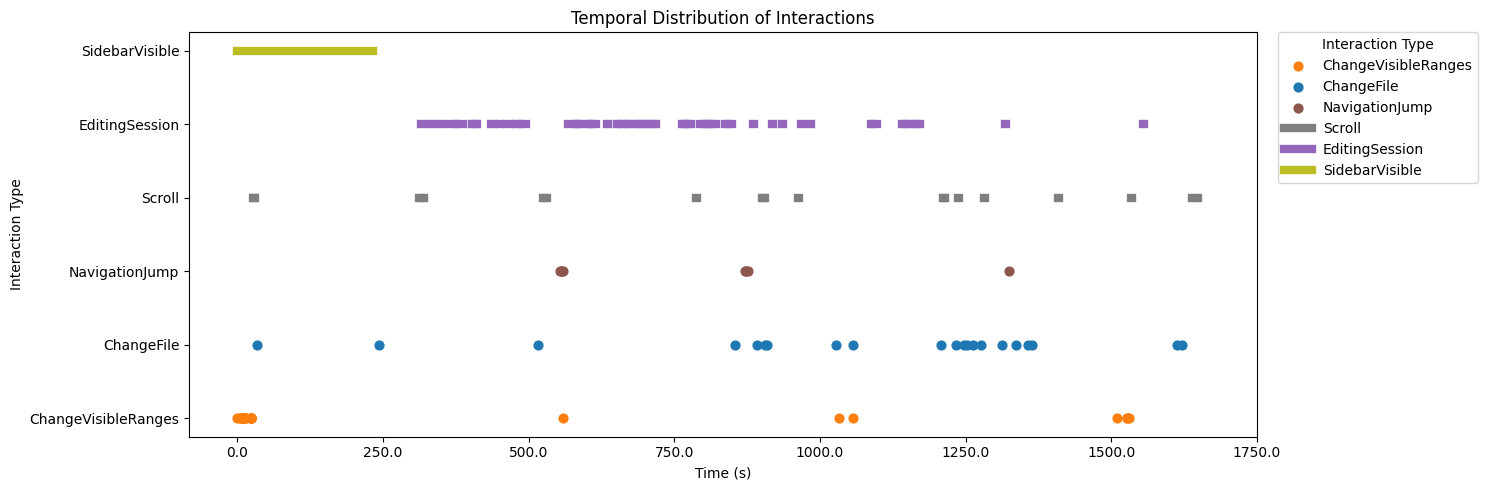


--- Participant P2 ---

Task Two
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 2, 'ChangeFile': 27, 'Scroll': 48, 'UnknownJump': 22, 'ChangeVisibleRanges': 41, 'EditingSession': 31, 'EditFile': 20, 'NavigationJump': 2})
Scrolling Distance: 550
Duration: 1463.529


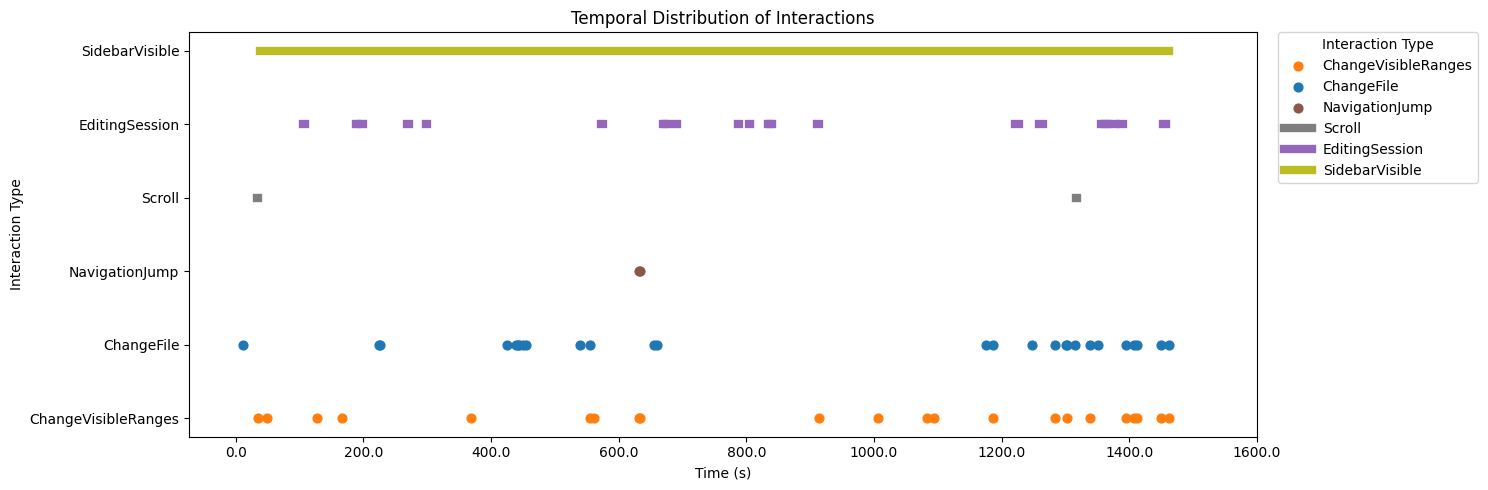


--- Participant P3 ---

Task Two
defaultdict(<class 'int'>, {'EditFile': 19, 'EditingSession': 50, 'ChangeFile': 47, 'ChangeVisibleRanges': 214, 'Scroll': 165, 'UnknownJump': 1150, 'ChangeSidebarVisibility': 3, 'NavigationJump': 4})
Scrolling Distance: 1851
Duration: 1611.695


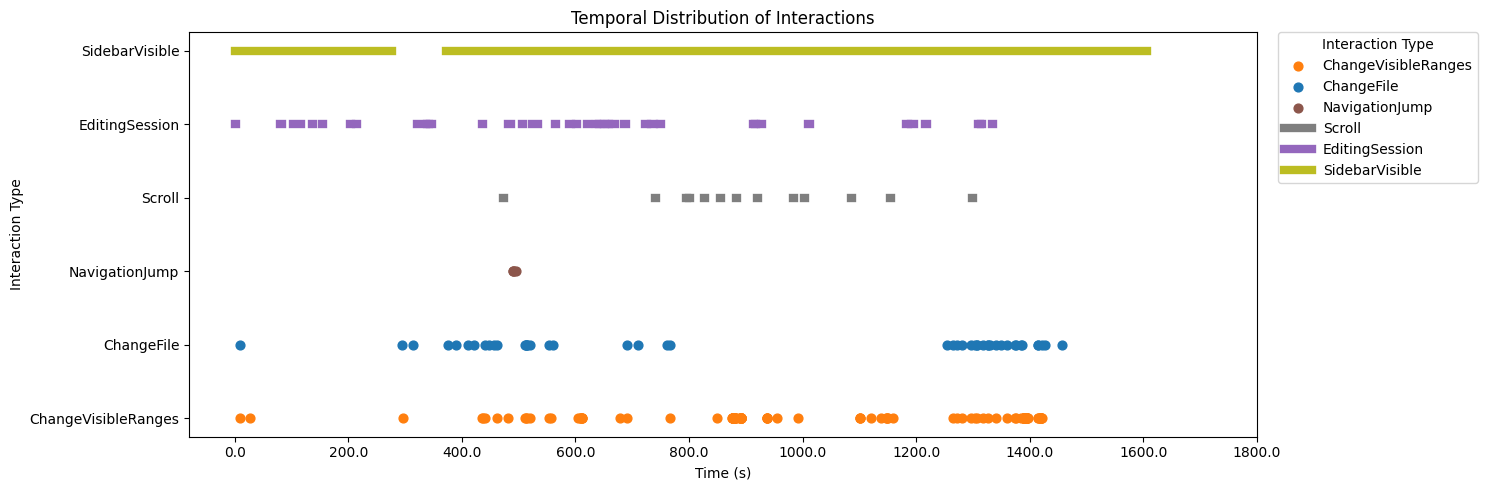


--- Participant P4 ---

Task One
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeFile': 5, 'ChangeVisibleRanges': 10, 'Scroll': 134, 'NavigationJump': 18, 'UnknownJump': 2, 'EditingSession': 41, 'EditFile': 7})
Scrolling Distance: 997
Duration: 959.115


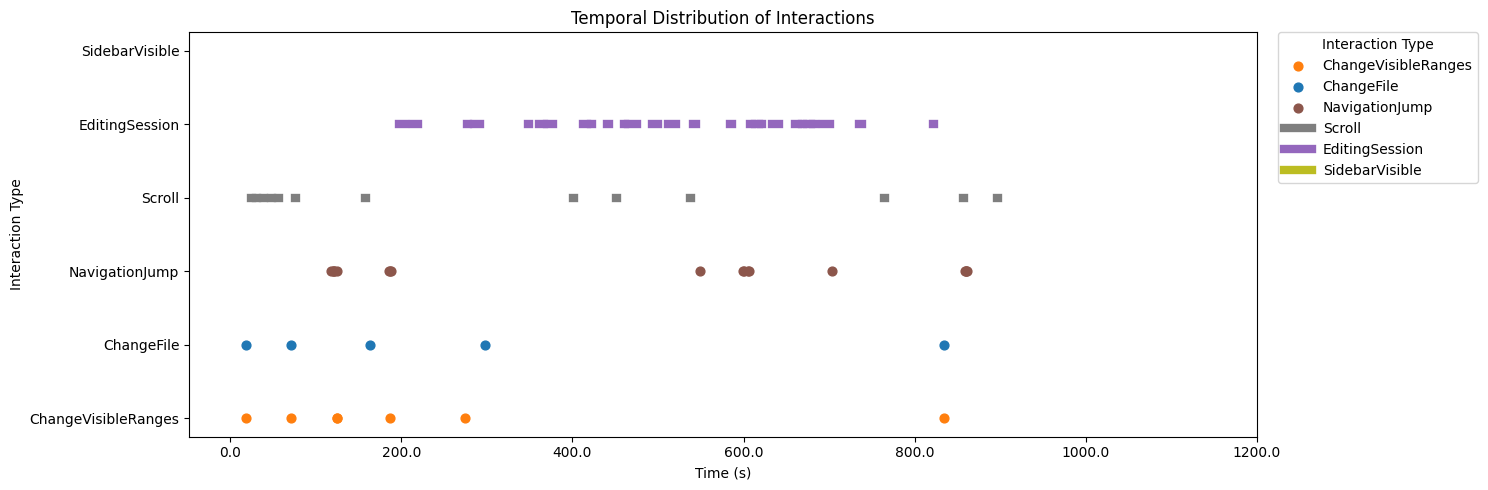


--- Participant P5 ---

Task One
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeFile': 41, 'UnknownJump': 14, 'Scroll': 163, 'ChangeVisibleRanges': 69, 'EditingSession': 14, 'EditFile': 15})
Scrolling Distance: 1540
Duration: 1544.923


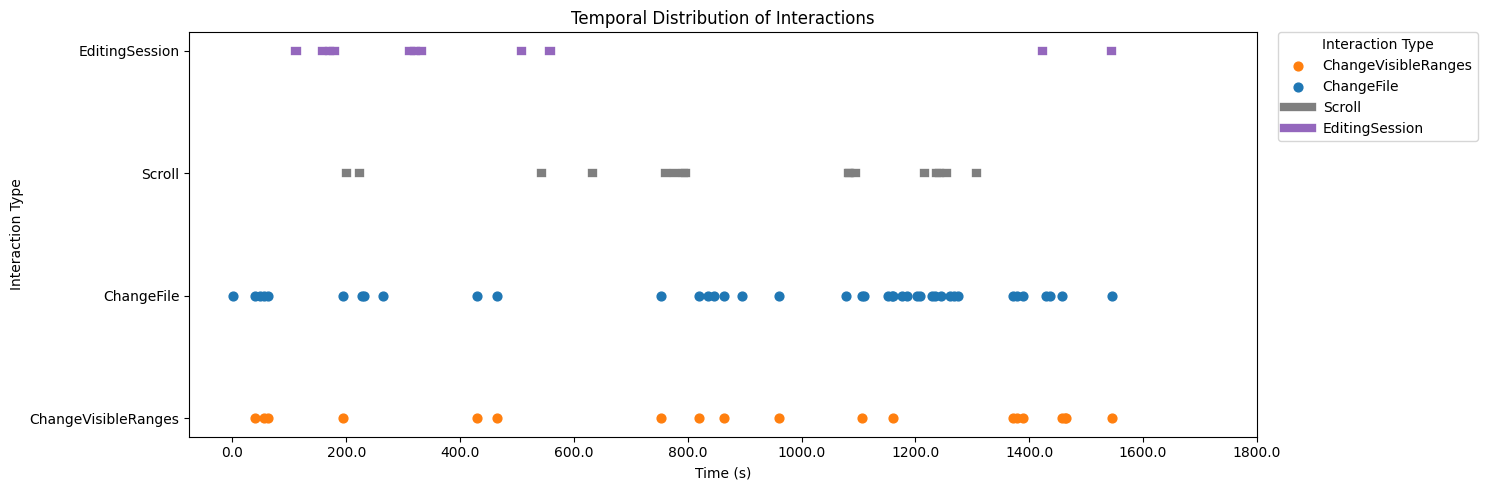


Task Two
defaultdict(<class 'int'>, {'Scroll': 114, 'UnknownJump': 7, 'ChangeVisibleRanges': 56, 'ChangeSidebarVisibility': 1, 'ChangeFile': 46, 'EditFile': 7, 'EditingSession': 9})
Scrolling Distance: 1215
Duration: 1425.996


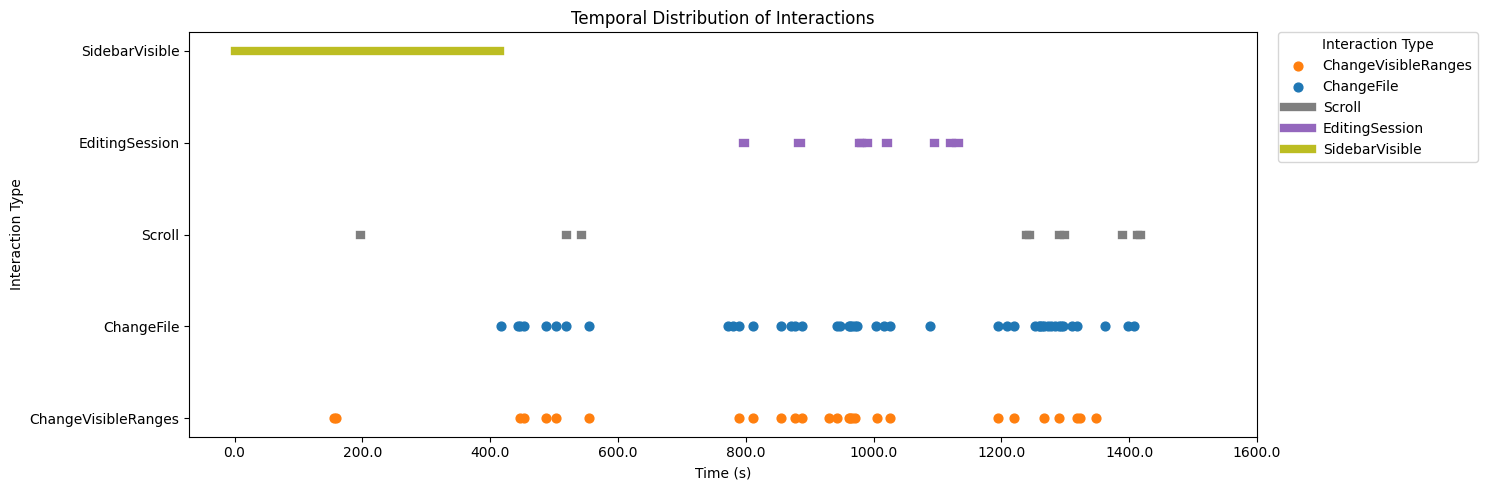


--- Participant P6 ---

Task One
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 2, 'ChangeFile': 16, 'ChangeVisibleRanges': 22, 'Scroll': 145, 'EditingSession': 13, 'EditFile': 11, 'SwitchView': 2, 'UnknownJump': 8, 'NavigationJump': 5})
Scrolling Distance: 1444
Duration: 928.31


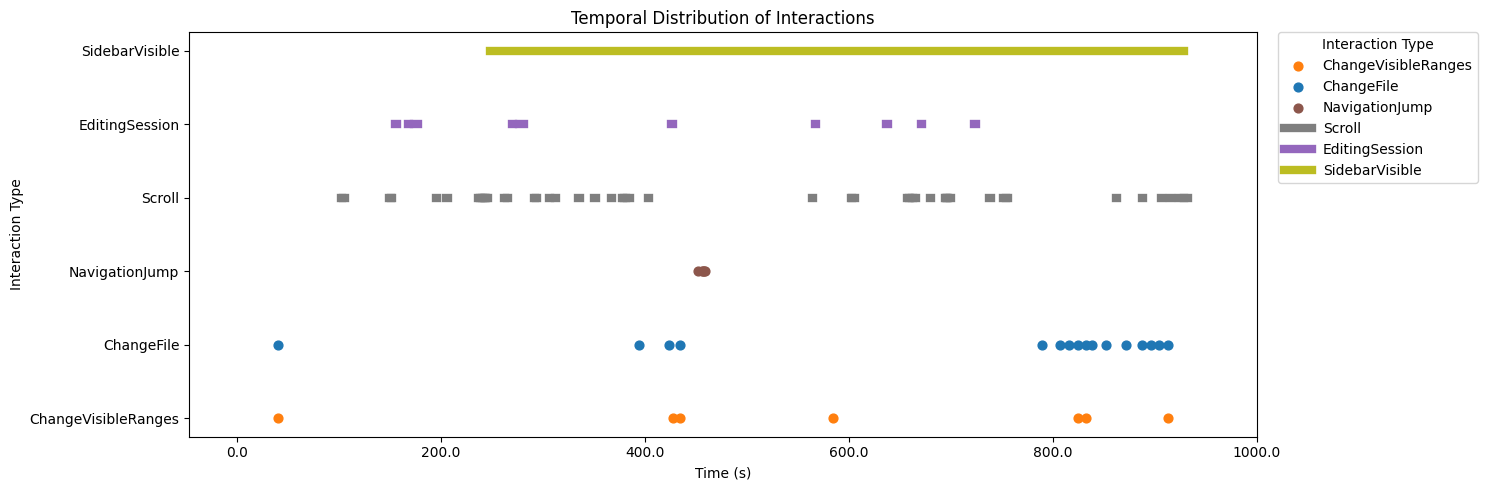


Task Two
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 2, 'Scroll': 97, 'ChangeFile': 29, 'UnknownJump': 10, 'EditingSession': 41, 'EditFile': 21, 'ChangeVisibleRanges': 48})
Scrolling Distance: 719
Duration: 1497.418


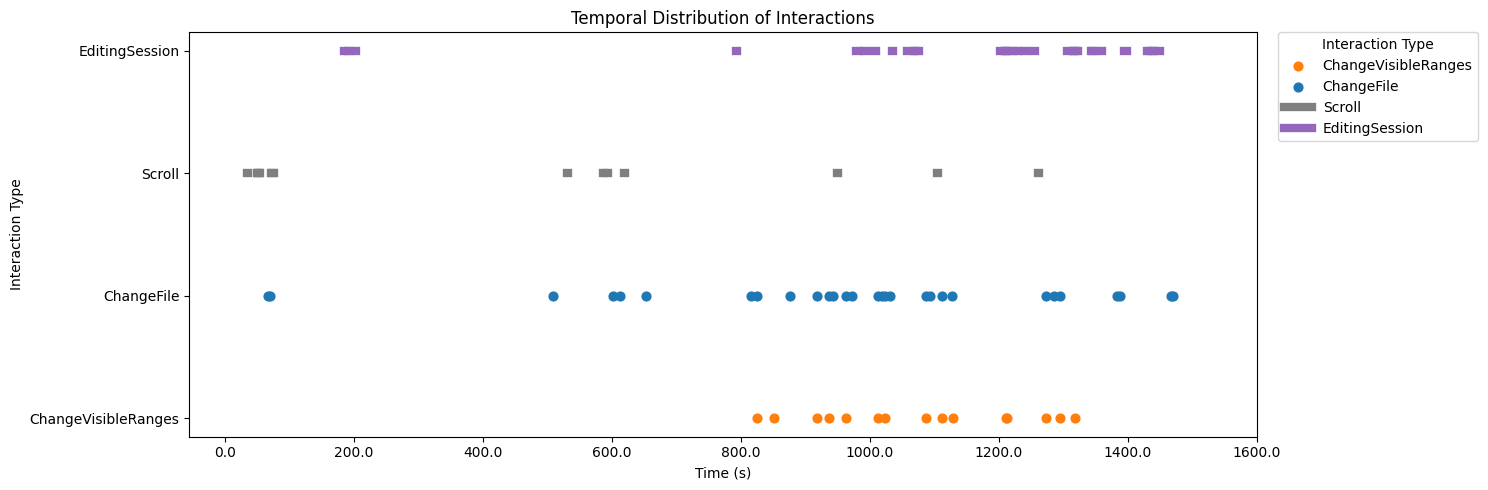


--- Participant P7 ---

Task One
defaultdict(<class 'int'>, {'Scroll': 147, 'ChangeFile': 14, 'ChangeVisibleRanges': 49, 'ChangeSidebarVisibility': 6, 'EditingSession': 23, 'EditFile': 11, 'UnknownJump': 5, 'NavigationJump': 8})
Scrolling Distance: 1543
Duration: 856.019


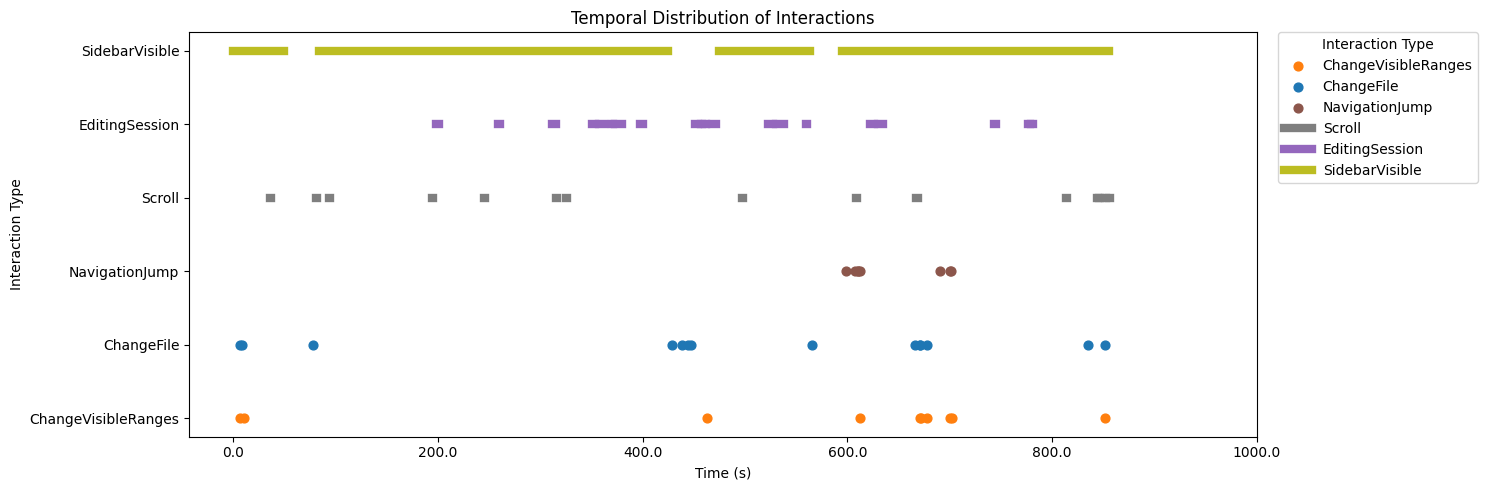


Task Two
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeVisibleRanges': 142, 'Scroll': 321, 'ChangeFile': 11, 'UnknownJump': 52, 'EditingSession': 31, 'EditFile': 11})
Scrolling Distance: 4257
Duration: 1761.019


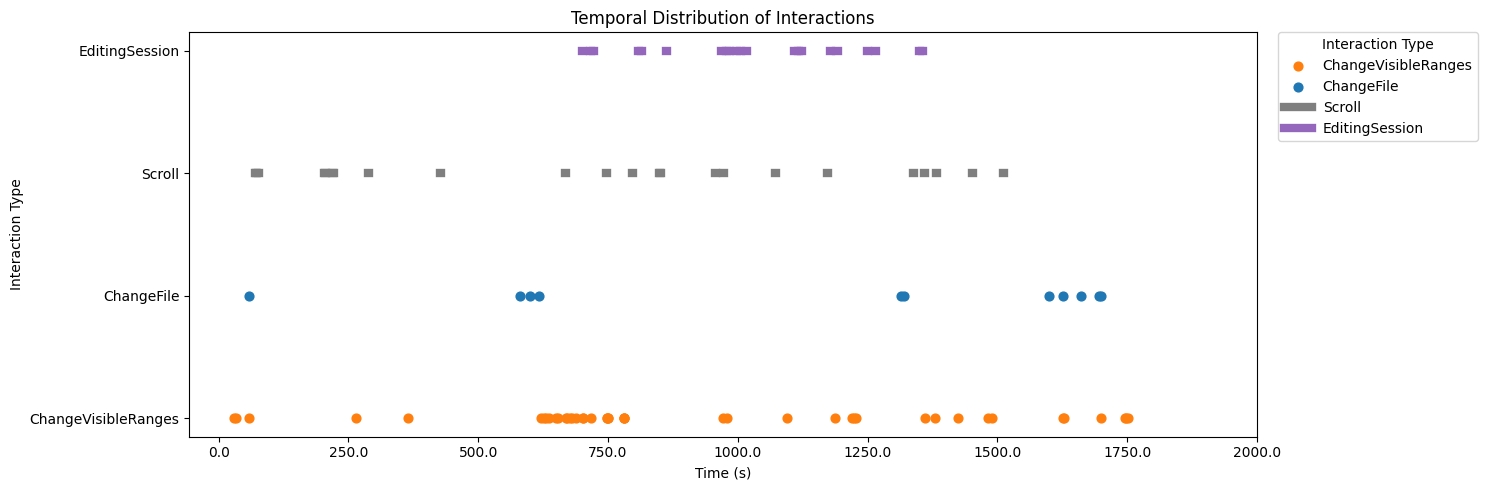


--- Participant P8 ---

Task One
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeFile': 27, 'ChangeVisibleRanges': 32, 'Scroll': 64, 'UnknownJump': 7, 'EditingSession': 26, 'EditFile': 11})
Scrolling Distance: 1109
Duration: 890.718


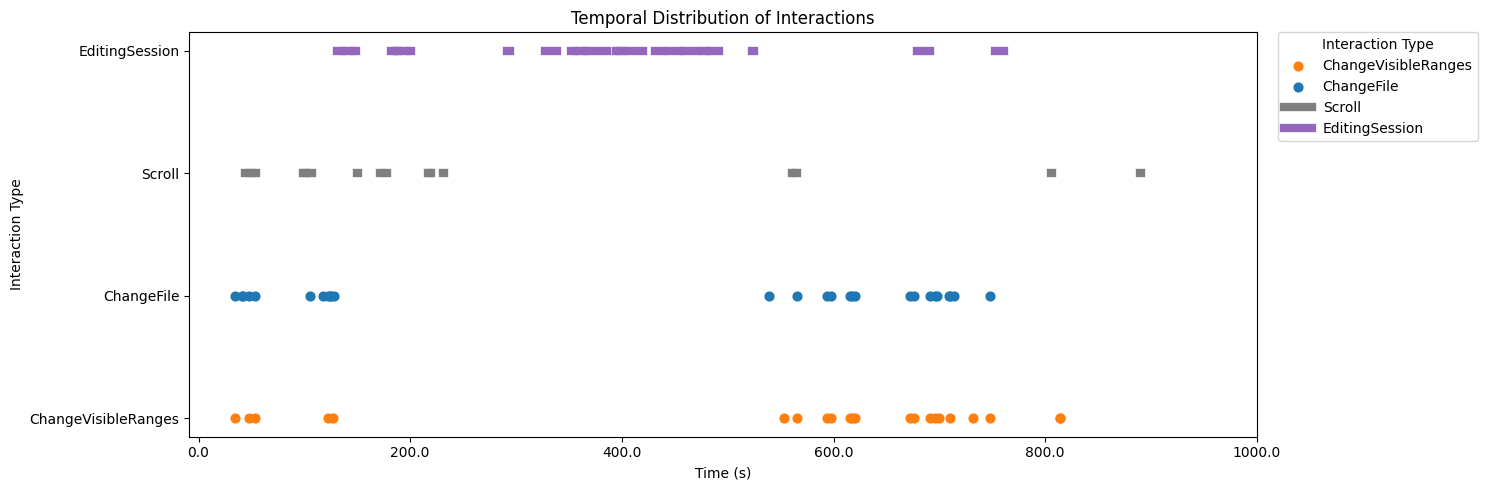


Task Two
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeFile': 60, 'UnknownJump': 32, 'EditFile': 27, 'Scroll': 39, 'ChangeVisibleRanges': 74, 'EditingSession': 48, 'NavigationJump': 3})
Scrolling Distance: 335
Duration: 1579.351


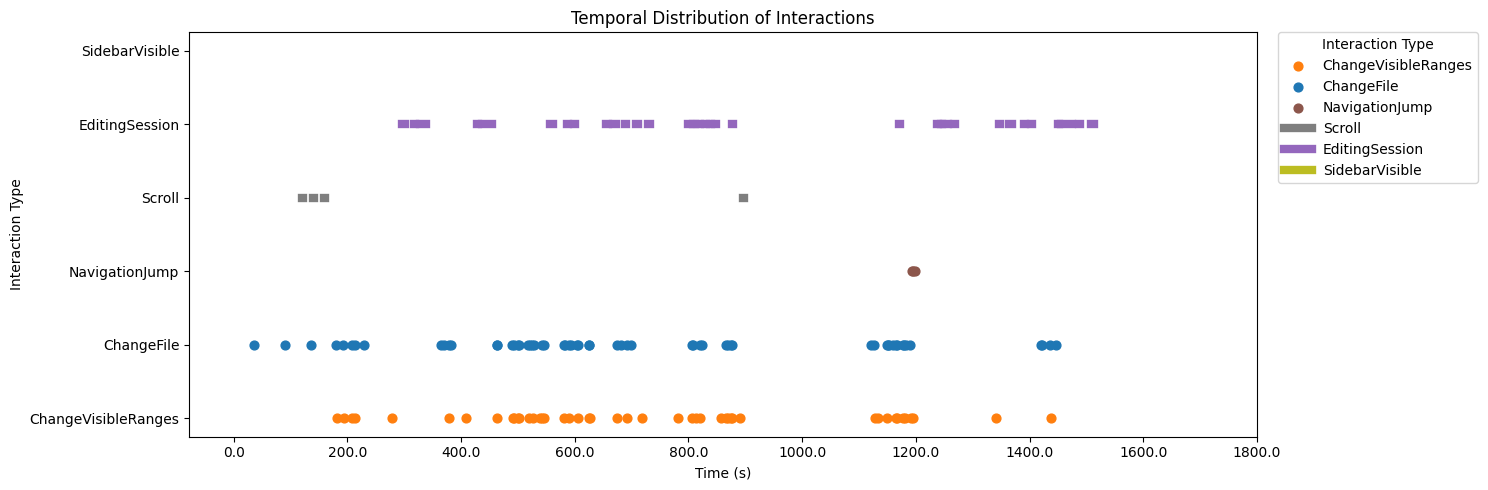


--- Participant P9 ---

Task One
defaultdict(<class 'int'>, {'ChangeVisibleRanges': 10, 'UnknownJump': 9, 'Scroll': 3, 'NavigationJump': 25, 'ChangeFile': 2, 'EditingSession': 2, 'ChangeSidebarVisibility': 2})
Scrolling Distance: 58
Duration: 984.195


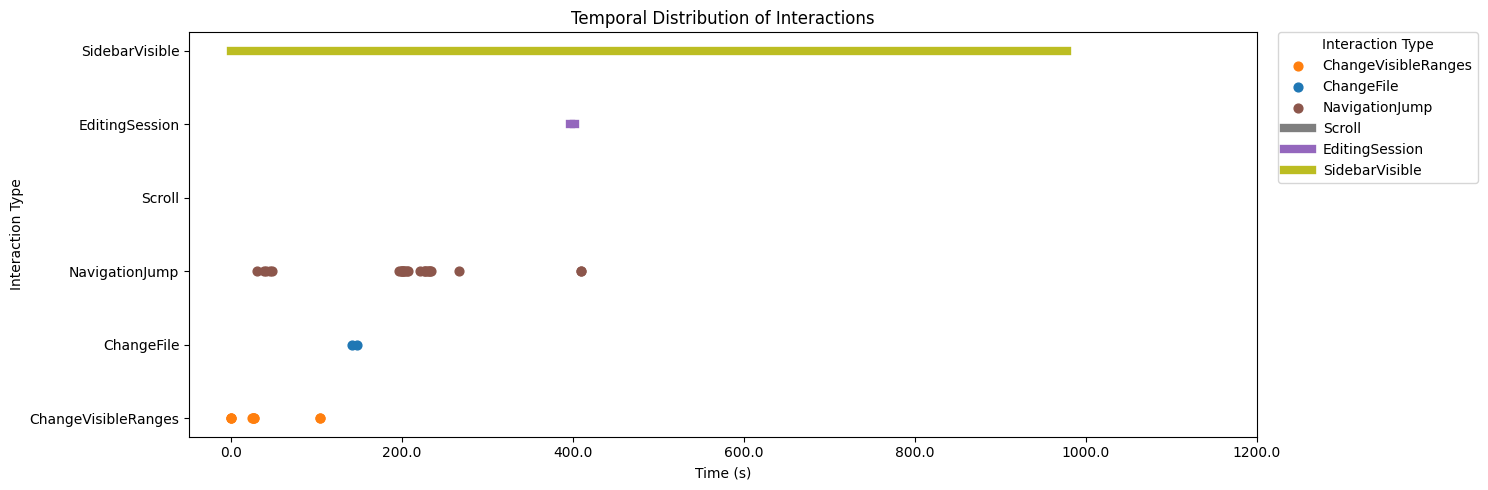

In [8]:
from interactions.plotting import plot_interactions

for participant in participants:
    print("\n--- Participant " + participant.name + " ---")

    if participant.interactionsTaskOne:
        print("\nTask One")
        print(countInteractions(participant.interactionsTaskOne))
        print(f"Scrolling Distance: {getScrollingDistance(participant.interactionsTaskOne)}")
        print(f"Duration: {(participant.interactionsTaskOne[-1]['timeStamp'] - participant.interactionsTaskOne[0]['timeStamp']) / 1000}")
        plot_interactions(participant.interactionsTaskOne, participant.evalTask == EvaluationTask.T1)

    if participant.interactionsTaskTwo:
        print("\nTask Two")
        print(countInteractions(participant.interactionsTaskTwo))
        print(f"Scrolling Distance: {getScrollingDistance(participant.interactionsTaskTwo)}")
        print(f"Duration: {(participant.interactionsTaskTwo[-1]['timeStamp'] - participant.interactionsTaskTwo[0]['timeStamp']) / 1000}")
        plot_interactions(participant.interactionsTaskTwo, participant.evalTask == EvaluationTask.T2)